# Frank-Wolfe on a Cone
## Problem

We want to solve

$$\min\limits_{x\in\mathbb{R}^{n}} \frac{1}{2}\|Ax-b\|^2 + \iota_{\mathcal{C}}(x)$$

where $A\in\mathbb{R}^{m\times n}$ and

$$\mathcal{C} = \{x:\|x\|_1\leq \rho\}$$

for some $\rho>0$.

The gradient of the objective function is given by

$$\nabla f(x) = A^*(Ax-b)$$

and the lmo is given by

$$\mathrm{lmo}(v) = -\rho[0,\ldots,1,\ldots,0]$$

where there is a $1$ in an index which has the greatest magnitude in $v$.

In [9]:
import numpy as np
import fw_functions as fw
import matplotlib.pyplot as plt

In [10]:
# Generate test data
n = int(1e4)  # dimension of the signal
m = int(5e2)  # number of measurements
np.random.seed(55)  # for reproducibility

# Generate sparse ground truth
X_ground_truth = np.zeros(n)
k = int(.001 * n)  # number of non-zero elements
non_zero_indices = np.random.choice(n, k, replace=False)
X_ground_truth[non_zero_indices] = 10 * np.random.rand(k)

# Generate measurement matrix
A = np.random.randn(m, n)
A /= np.linalg.norm(A, axis=1, keepdims=True)  # normalize rows

# Generate measurements
b = A @ X_ground_truth

# Initial point (random point in the L1 ball)
X0 = np.zeros(n)

# L1 ball radius (assuming we know an upper bound on the L1 norm of X_ground_truth)
radius = 1.0

# Objective function (least squares with L1 constraint)
class L1ConstrainedLeastSquares(fw.ObjectiveFunction):
    def __init__(self, A, b):
        self.A = A
        self.b = b
    
    def evaluate(self, x):
        return 0.5 * np.linalg.norm(self.A @ x - self.b)**2
    
    def gradient(self, x):
        return self.A.T @ (self.A @ x - self.b)

# Create the objective function
objective = L1ConstrainedLeastSquares(A, b)

# Create the LMO for the L1 ball
lmo = fw.create_lmo(radius, "nonnegative_orthant")

# Print some information about the generated data
print(f"Ground truth sparsity: {np.sum(X_ground_truth != 0)} / {n}")
print(f"L1 norm of ground truth: {np.linalg.norm(X_ground_truth, ord=1)}")
print(f"L1 ball radius: {radius}")

# L = np.linalg.norm(A.T@A, ord=2)
L = 1.489369552621312

Ground truth sparsity: 10 / 10000
L1 norm of ground truth: 49.98137462034511
L1 ball radius: 1.0


Away Frank-Wolfe Progress:   0%|          | 0/10000 [00:00<?, ?it/s]/Users/cvntsf/GitHub/frankwolfe/fw_variants/conic/fw_functions.py:149: RuntimeWarning: divide by zero encountered in scalar divide
  gamma = min(gap_away/(self.L * np.linalg.norm(away_vertex)**2), gamma_max)
Away Frank-Wolfe Progress:   0%|          | 13/10000 [00:00<01:23, 120.24it/s]

Away step occurred


Away Frank-Wolfe Progress: 100%|██████████| 10000/10000 [01:45<00:00, 95.11it/s]


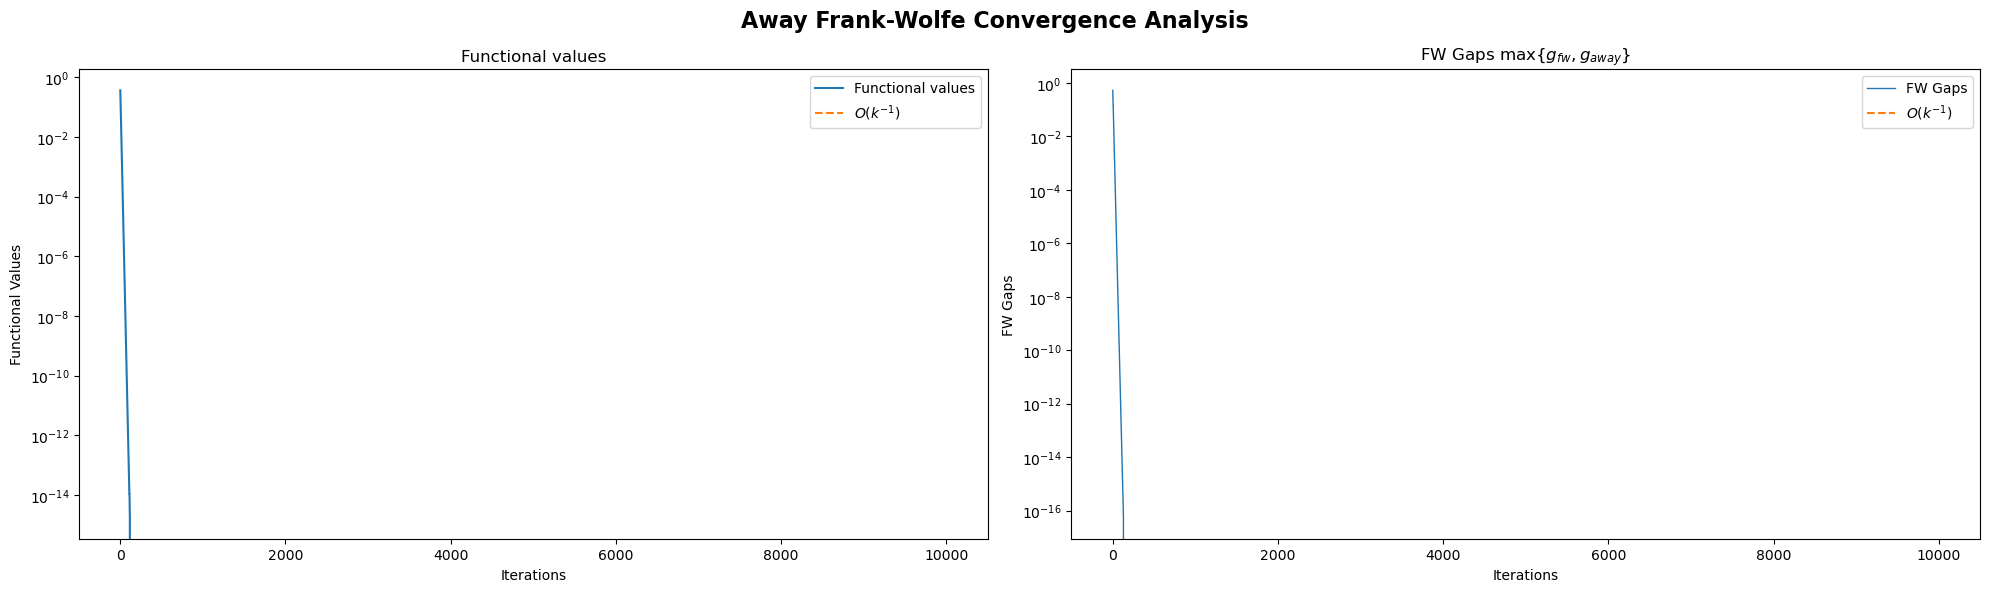

In [11]:
# Initialize and run the Away Frank-Wolfe algorithm
cfw = fw.ConicFrankWolfe(objective, lmo, L)
cfw.run(X0, n_steps=10000, tol=1e-11, step_rule = 'none')

# Plot the convergence
cfw.plot_convergence()

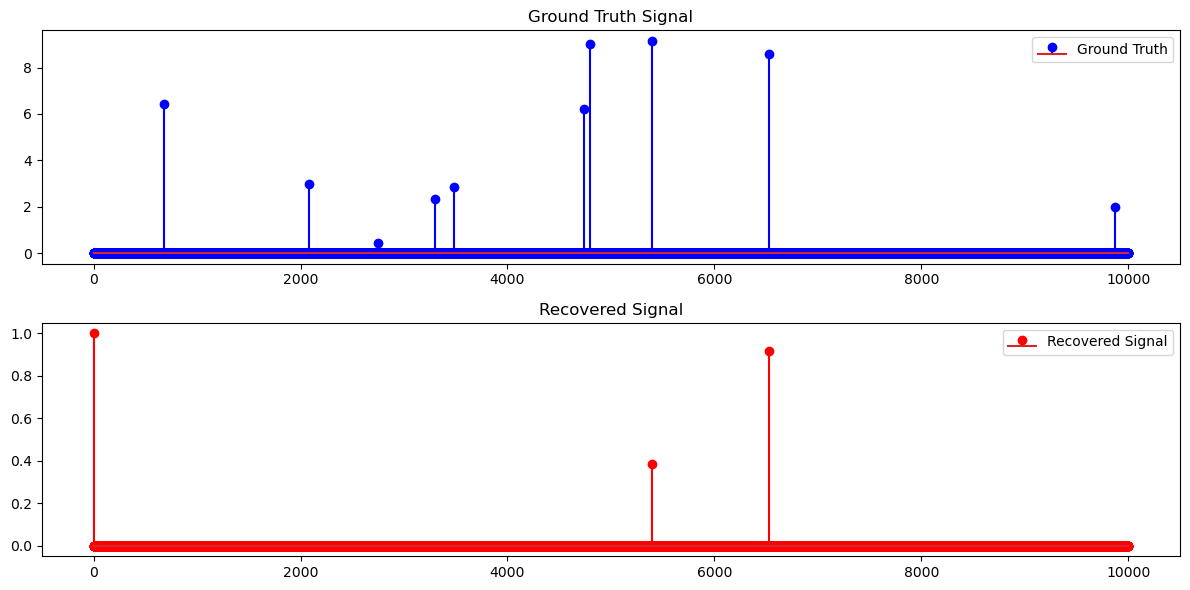

L1 error: 49.67878696226148
L2 error: 17.997620483212273
Recovered signal sparsity: 3 / 10000


In [12]:
# Compare the recovered signal with the ground truth
recovered_signal = cfw.x

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(X_ground_truth, markerfmt='bo', linefmt='b-', label='Ground Truth')
plt.title('Ground Truth Signal')
plt.legend()

plt.subplot(2, 1, 2)
plt.stem(recovered_signal, markerfmt='ro', linefmt='r-', label='Recovered Signal')
plt.title('Recovered Signal')
plt.legend()

plt.tight_layout()
plt.show()

# Print some metrics
print(f"L1 error: {np.linalg.norm(X_ground_truth - recovered_signal, ord=1)}")
print(f"L2 error: {np.linalg.norm(X_ground_truth - recovered_signal)}")
print(f"Recovered signal sparsity: {np.sum(np.abs(recovered_signal) > 1e-6)} / {n}")